MICRO GRAD ON GITHUB IS AND AUTO GRAD ENGINE -- AUTOMATIC GRADIENT -- IT IMPLEMENTS BACK PROPAGATION -- AN ALGO THAT EFFIECIENTLY EVALUATES THE GRADIENT USING SOME KIND OF A LOSS FUNCTION WRT WEIGHTS OF A NEURAL NETWORK and that allows us to tune weights of NN to minimize loss and increase accuracy of the network!



In [1]:
from micrograd.engine import Value


chain rule, back propagation, tensors and dim reductionality.


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def f(x):
    return 3*x**2 - 4*x +5

In [4]:
f(3.0)

20.0

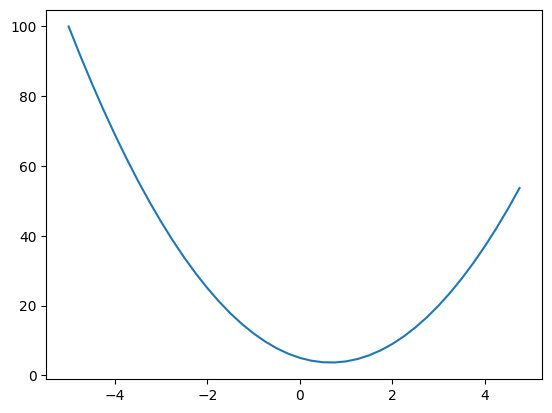

In [5]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [6]:
# Derivative is f(a+h) - f(a) / h (limit h -> 0) --> slope of the function.
# HOW SENSITIVE IS THE FUNCTION TO A LITTLE BUMP IN H IS THE Whole IDEA

h = 0.0000001
x = 2/3
(f(x + h) - f(x))/h # respond


2.9753977059954195e-07

In [7]:
# lets get more complex
# function of three scalar inputs

a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [8]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b +c

print('d1',d1)
print('d2',d2)
print('slope', (d2-d1)/h)


# gives me intuitive sense of what derivatiev does

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [9]:
# single scalar value that wraps and keeps a track of value,and repr function used to return string
# children is a tuple in here

# isinstance(other, Value), Checks if other is already an instance of the Value class (or a subclass).

class Value:

    def __init__(self,data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data= {self.data})" # repr function to get string value
    # Python doesn't know how to add value objects.
    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self,other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
        
    def __mul__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self,other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        # assertion error raised if necc.
        assert isinstance(other, (int, float)), "only supporting int/float powers as of now"
        out = Value(self.data ** other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad 
            # chained to out grad
        out._backward = _backward

        return out
    
    def __rmul__(self, other):
        return self * other

    def __radd__(self,other):
        return self + other

    def __truediv__(self, other):
        return self * other**-1

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward ():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
        
    def backward(self):
        # The node will be in the list only once all of it's children are in the list
        topo = []
        visited = set()
        
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

## grads are accumulated cause it might get replaced by new grad in fully connected NN

In [10]:
import graphviz
from graphviz import Digraph

In [11]:
def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape= 'record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1,n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot
             

# grad in each is  derivative of out put w.r.t weight of that node.

L = d * f
dL/dd = f

(f(x + h) - f(x))/h # derivatie fromula h tending to 0.

#proof
((d+h)*f - d*f) / h = f


# Crux of Back Propagation  
# deriving C wrt L 

d = c + e

dd/dc = 1


dd / de = 1

WANT :
dL / dc = (dL / dd) * (dd / dc) 

KNOWN DERVS:
dL / dd
dd / dc

similarly da




## Simply put backward propagation is recursive application of chain rule

## Back propagation through a single neuron

# activation function is a squashing function like either a sigmoid or tanh

# Output is activation function appliued through dot products and weights

In [12]:
# inputs x1`,x2
x1 = Value(2.0, label = 'x1');
x2 = Value(0.0, label = 'x2');

# weights w1,w2
w1 = Value(-3.0, label = 'w1');
w2 = Value(1.0, label = 'w2');

# bias of a neuron
b = Value(6.8813735870195432, label = 'b');

# x1w1 + x2w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1';
x2w2 = x2 * w2; x2w2.label = 'x2*w2';
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

# output
o = n.tanh(); o.label = 'o'
o.backward()

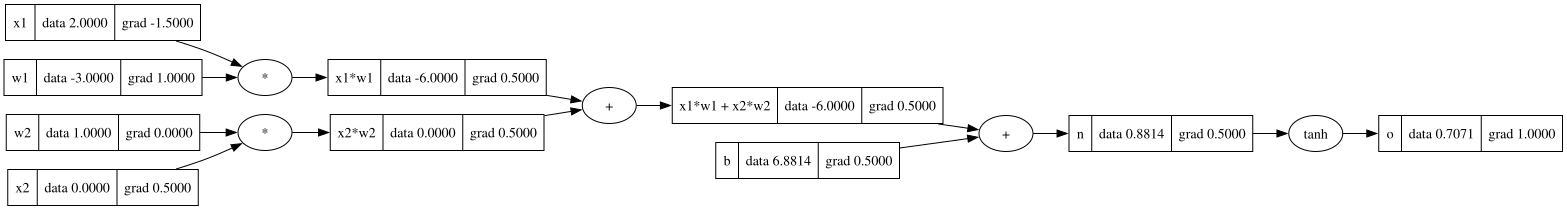

In [13]:
draw_dot(o)

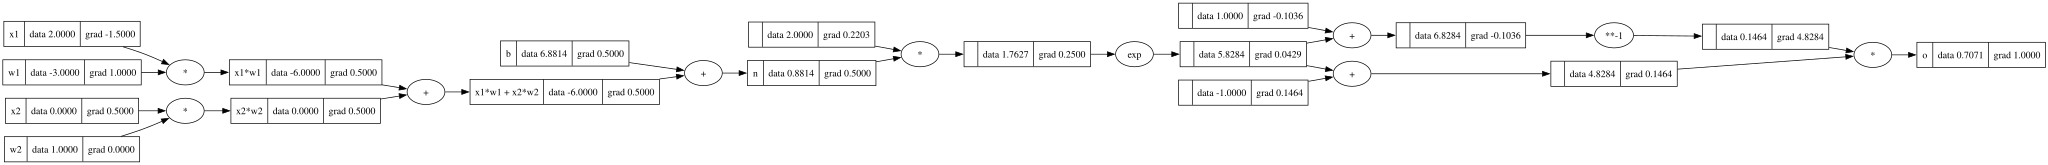

In [14]:
# inputs x1`,x2
x1 = Value(2.0, label = 'x1');
x2 = Value(0.0, label = 'x2');

# weights w1,w2
w1 = Value(-3.0, label = 'w1');
w2 = Value(1.0, label = 'w2');

# bias of a neuron
b = Value(6.8813735870195432, label = 'b');

# x1w1 + x2w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1';
x2w2 = x2 * w2; x2w2.label = 'x2*w2';
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

# ------ instead of tanh (equivalent of tanh)

e = (2*n).exp()
o = (e - 1) / (e + 1)
# --------
# output
o.label = 'o'
o.backward()
draw_dot(o)

In [15]:
import torch
import math

In [16]:
x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True

x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True
w2 = torch.Tensor([1.0]).double() ; w2.requires_grad = True

b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True

n = x1*w1 + x2*w2 + b

o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [17]:
# Defining a single neuron
import random
class Neuron:

    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for t in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w = x*b 
        weightedsum = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = weightedsum.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]
        
# Defining a layer of neurons
class Layer:
# nout is no. of neurons you want in a single layer
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for t in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        
            
# Defining multiple layers (A MultiLayer Perceptron)
class MLP:
    def __init__(self, nin, nouts):
        size = [nin] + nouts # concats input size(cahnged to list before concat) w outputs/ neuron count in each layer
        self.layers = [Layer(size[i], size[i+1]) for i in range(len(nouts))]
    # Forward Pass :)
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    

x = [2.0, 3.0, -1.0] # inputs
n = MLP(3, [4,4,1])
n(x)

Value(data= -0.8239241428002062)

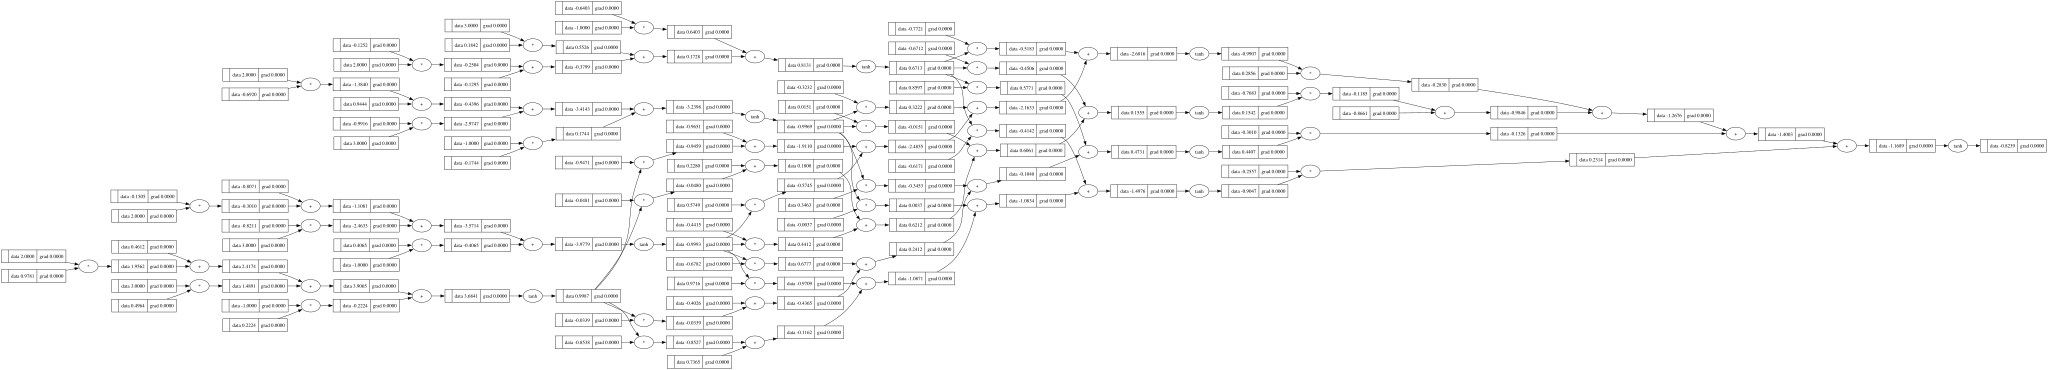

In [18]:
draw_dot(n(x))

In [19]:
# inputs
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

# targets
ys = [ 1.0, -1.0, -1.0, 1.0 ]

# trying to emulate a binary classifier anthe

# predictions

## Now how do I tune weights so that we achieve better predictions/ outputs tending to targets ?

In [23]:
 for k in range(20):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    # update
    loss.backward()

    for p in n.parameters():
        p.data += -0.05 * p.grad 

    print(k, loss.data)

0 0.01234668114587895
1 0.012106102939803041
2 0.011874291636622455
3 0.011650786825766701
4 0.011435159365631917
5 0.011227008796764186
6 0.011025961005994291
7 0.010831666113716113
8 0.010643796559953744
9 0.010462045367841028
10 0.010286124565714774
11 0.010115763751255093
12 0.009950708783048486
13 0.009790720586637191
14 0.009635574063591966
15 0.009485057093434857
16 0.00933896961936407
17 0.009197122809725447
18 0.00905933828804225
19 0.008925447425183497
